In [ ]:
!pip install torch transformers sentence-transformers datasets evaluate mabwiser rank_bm25
!pip install faiss-cpu --no-cache
!pip install mabwiser --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
import faiss
import sentence_transformers
import mabwiser

print("Torch version:", torch.__version__)
print("FAISS version:", faiss.__version__)
print("Sentence-Transformers version:", sentence_transformers.__version__)


Torch version: 2.6.0+cu124
FAISS version: 1.11.0
Sentence-Transformers version: 3.4.1


In [ ]:
import random
import numpy as np

random.seed(42)          # control Python's randomness
np.random.seed(42)       # control NumPy's randomness

In [ ]:
from datasets import load_dataset

# Load the SQuAD dataset (much faster)
dataset = load_dataset("squad", split="train[:5300]")

# Extract relevant fields
documents = [d["context"][:500] for d in dataset]  # Shorter passages ******
questions = [d["question"] for d in dataset]

print(f"Loaded {len(documents)} documents and {len(questions)} questions.")
print("Example Question:", questions[0])
print("Example Document:", documents[0][:300], "...")


README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Loaded 5000 documents and 5000 questions.
Example Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Example Document: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is  ...


In [ ]:
import re
from rank_bm25 import BM25Okapi

# Preprocessing function (Tokenize documents)
def preprocess(text):
    return [word.lower() for word in re.findall(r'\w+', text)]

# Tokenize all documents for BM25
tokenized_docs = [preprocess(doc) for doc in documents]

# Initialize BM25 model

bm25 = BM25Okapi(tokenized_docs)

print("BM25 Indexing Complete!")


BM25 Indexing Complete!


# **Some Hyperparams**

In [ ]:
BETA = 0.0005

# Shared training size for all models
TRAINING_SIZE = 5000
TEST_SIZE = 300

# discrete action space
TOP_K_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
LAMBDA_VALUES = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
TAU_VALUES = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]
#TOP_K_VALUES = [1, 3, 5, 7, 10]
#LAMBDA_VALUES = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
#TAU_VALUES = [0.6, 0.65, 0.7, 0.75]

# **Training set**

In [ ]:
from tqdm import tqdm
import random

# Generate initial training data using random actions
train_queries = random.sample(questions, TRAINING_SIZE)

In [ ]:
import faiss
import torch
from sentence_transformers import SentenceTransformer

# Load a sentence-transformer model
dense_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
#sentence-transformers/msmarco-MiniLM-L12-cos-v5
# sentence-transformers/all-MiniLM-L6-v2

# Compute dense embeddings for the corpus
corpus_embeddings = dense_model.encode(documents, convert_to_tensor=True)

# Create a FAISS index for fast retrieval
faiss_index = faiss.IndexFlatL2(corpus_embeddings.shape[1])
faiss_index.add(corpus_embeddings.cpu().numpy())

print("Dense Retrieval Index Built!")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dense Retrieval Index Built!


# **Pre-encode**

In [ ]:
from tqdm import tqdm
import numpy as np

# Document Embeddings (Batched)
print("Encoding documents (batched)...")
encode_batch_size = 32
doc_embeddings = []

for i in tqdm(range(0, len(documents), encode_batch_size), desc="Documents"):
    batch = documents[i:i+encode_batch_size]
    embs = dense_model.encode(batch, normalize_embeddings=True)
    doc_embeddings.append(embs)

doc_embeddings = np.vstack(doc_embeddings)
doc_idx_map = {doc: i for i, doc in enumerate(documents)}

# Query Embeddings (Batched)
print("Encoding training queries (batched)...")
query_embeddings = []

for i in tqdm(range(0, len(train_queries), encode_batch_size), desc="Queries"):
    batch = train_queries[i:i+encode_batch_size]
    embs = dense_model.encode(batch, normalize_embeddings=True)
    query_embeddings.append(embs)

query_embeddings = np.vstack(query_embeddings)



Encoding documents (batched)...


Documents: 100%|██████████| 157/157 [00:05<00:00, 31.22it/s]


Encoding training queries (batched)...


Queries: 100%|██████████| 125/125 [00:01<00:00, 113.52it/s]


# **Hybrid retrieval function**

In [ ]:
from heapq import nlargest

def hybrid_retrieve(query, top_k, lambda_weight,
                    query_embedding=None, doc_embeddings=None, doc_idx_map=None):
    # BM25 retrieval
    query_tokens = preprocess(query)
    bm25_indices = bm25_top_k(query_tokens, bm25, top_k * 2)

    bm25_max_rank = len(bm25_indices) - 1
    bm25_scores = {
        idx: 1 - (rank / bm25_max_rank) if bm25_max_rank > 0 else 1.0
        for rank, idx in enumerate(bm25_indices)
    }

    # Dense retrieval
    if query_embedding is None:
        query_embedding = dense_model.encode([query])[0]
        query_embedding = query_embedding / np.linalg.norm(query_embedding)

    if doc_embeddings is not None:
        sims = np.dot(doc_embeddings, query_embedding)
        dense_indices = np.argsort(sims)[-top_k * 2:][::-1]
        dense_scores = {idx: sims[idx] for idx in dense_indices}
    else:
        query_tensor = dense_model.encode([query], convert_to_tensor=True)
        _, dense_indices = faiss_index.search(query_tensor.cpu().numpy(), k=top_k * 2)
        dense_indices = dense_indices[0].tolist()
        dense_scores = {idx: 1.0 for idx in dense_indices}

    # Combine scores
    all_indices = set(bm25_scores) | set(dense_scores)
    hybrid_scores = {
        idx: lambda_weight * bm25_scores.get(idx, 0) + (1 - lambda_weight) * dense_scores.get(idx, 0)
        for idx in all_indices
    }

    # Return top-k documents
    sorted_indices = sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)
    return [documents[idx] for idx, _ in sorted_indices[:top_k]]



from heapq import nlargest

def bm25_top_k(query_tokens, bm25_model, k):
    scores = bm25_model.get_scores(query_tokens)
    return np.argsort(scores)[-k:][::-1].tolist()



**Simple test**

In [ ]:
import random

# Select a random query from the dataset
query_index = random.randint(0, len(questions) - 1)  # Pick a random question
query = questions[query_index]  # Fetch the query
ground_truth_document = documents[query_index]  # The corresponding document (for reference)

print(f"Query: {query}")

# Perform hybrid retrieval
#retrieved_docs = hybrid_retrieve(query, top_k=3, lambda_weight=0.6)
retrieved_docs = hybrid_retrieve(query, top_k=3, lambda_weight=0.6, doc_embeddings=doc_embeddings, doc_idx_map=doc_idx_map)

# Display retrieved documents
for i, doc in enumerate(retrieved_docs):
    print(f"\nTop {i+1} Retrieved Document:\n{doc[:300]}...")

# Optional: Compare with ground truth
print("\nGround Truth Document:\n", ground_truth_document[:300], "...")


Query: In what year did the population of New York first reach an all-time high in this period?

Top 1 Retrieved Document:
An earlier draft of To Kill a Mockingbird, titled Go Set a Watchman, was controversially released on July 14, 2015. This draft, which was completed in 1957, is set 20 years after the time period depicted in To Kill a Mockingbird but is not a continuation of the narrative. This earlier version of the...

Top 2 Retrieved Document:
An earlier draft of To Kill a Mockingbird, titled Go Set a Watchman, was controversially released on July 14, 2015. This draft, which was completed in 1957, is set 20 years after the time period depicted in To Kill a Mockingbird but is not a continuation of the narrative. This earlier version of the...

Top 3 Retrieved Document:
An earlier draft of To Kill a Mockingbird, titled Go Set a Watchman, was controversially released on July 14, 2015. This draft, which was completed in 1957, is set 20 years after the time period depicted in To Kill 

# **Retrieval evaluation functions**

In [ ]:
import numpy as np

def evaluate_retrieval(query, top_k, lambda_weight, tau, beta=BETA,
                       query_embedding=None, doc_embeddings=None, doc_idx_map=None):# beta=0.0002

    retrieved_docs = hybrid_retrieve(
        query, top_k, lambda_weight,
        query_embedding=query_embedding,
        doc_embeddings=doc_embeddings,
        doc_idx_map=doc_idx_map
    )
    #retrieved_docs = hybrid_retrieve(query, top_k=top_k, lambda_weight=lambda_weight)

    ground_truth_doc = documents[questions.index(query)]

    alpha = 1-beta

    # Simple relevance score: max similarity with ground truth
    def simple_overlap(doc1, doc2):
        tokens1 = set(doc1.lower().split())
        tokens2 = set(doc2.lower().split())
        return len(tokens1 & tokens2) / len(tokens1 | tokens2)

    overlaps = [(doc, simple_overlap(doc, ground_truth_doc)) for doc in retrieved_docs]
    filtered = [doc for doc, sim in overlaps if sim >= tau]
    relevance_score = max([sim for _, sim in overlaps if sim >= tau], default=0)
    token_cost = sum(len(doc.split()) for doc in filtered)

    diversity_score = len(set(doc[:30] for doc in filtered)) / (len(filtered) + 1e-6)

    penalty_k = 0.01 * (10 - top_k)  # encourage higher k
    penalty_tau = 0.05 * (0.8 - tau)
    #normalized_cost = token_cost/top_k
    normalized_cost = token_cost

    # reward
    '''reward = (
        alpha * relevance_score +            # relevance
        0.2 * diversity_score -              # encourage diverse docs
        beta * token_cost                    # discourage long answers
    )'''

    reward = alpha * relevance_score - beta * normalized_cost - penalty_tau
    #reward = alpha * relevance_score - beta * token_cost
    #reward = relevance_score

    return reward, relevance_score, token_cost



In [ ]:
from multiprocessing import Pool

def evaluate_query_worker(args):
    query, query_embedding, action, beta = args

    # Determine if action is an index or tuple
    if isinstance(action, int):  # MAB or CMAB
        top_k, lambda_weight, tau = action_map[action]
    else:  # PPO: directly use the tuple
        top_k, lambda_weight, tau = action

    reward, score, token_cost = evaluate_retrieval(
        query=query,
        top_k=top_k,
        lambda_weight=lambda_weight,
        tau=tau,
        beta=beta,
        query_embedding=query_embedding,
        doc_embeddings=doc_embeddings,
        doc_idx_map=doc_idx_map
    )
    return action, reward, score, token_cost



def parallel_evaluate(queries, query_embeddings, actions=None, beta=BETA, num_workers=4):
    args = []

    if actions is None:
        # MAB/CMAB training — sample random discrete action_id
        actions = [random.choice(list(action_map.keys())) for _ in queries]

    for i in range(len(queries)):
        args.append((queries[i], query_embeddings[i], actions[i], beta))

    results = []
    with Pool(num_workers) as pool:
        for out in tqdm(pool.imap_unordered(evaluate_query_worker, args), total=len(args)):
            results.append(out)

    selected_actions = [r[0] for r in results]  # int for MAB/CMAB, tuple for PPO
    rewards = [r[1] for r in results]
    scores = [r[2] for r in results]

    return selected_actions, rewards, scores




# **Training**

# **MAB with Eps-Greedy (No Context)**

In [ ]:
from mabwiser.mab import MAB, LearningPolicy
import random
import numpy as np
from tqdm import tqdm

# Initialize the MAB model
from mabwiser.mab import MAB, LearningPolicy
import random
from torch.distributions import Categorical, Normal

def binarize_reward(reward, threshold=0.75):
    """Convert numerical reward to binary (1 if above threshold, else 0)."""
    return 1 if reward >= threshold else 0


# Create indexed action map
action_map = {
    idx: (k, lam, tau)
    for idx, (k, lam, tau) in enumerate(
        (k, lam, tau) for k in TOP_K_VALUES for lam in LAMBDA_VALUES for tau in TAU_VALUES
    )
}
actions = list(action_map.keys())

# Define retrieval action space
actions = list(range(len(action_map)))  # Available action indices

# Training history (store decisions as scalars)
selected_actions, rewards = [], []

scores = []

print("Starting MAB training...")
print("Using parallel reward evaluation...")
selected_actions, rewards, scores = parallel_evaluate(
    queries=train_queries,
    query_embeddings=query_embeddings,
    beta=BETA,
    num_workers=16
)


#mab = MAB(arms=actions, learning_policy=LearningPolicy.EpsilonGreedy(epsilon=0.1))
mab = MAB(arms=list(action_map.keys()), learning_policy=LearningPolicy.EpsilonGreedy(epsilon=0.05))

#mab = MAB(arms=actions, learning_policy=LearningPolicy.ThompsonSampling())


# Train MAB model using initial data
mab.fit(np.array(selected_actions), np.array(rewards))


print(f"MAB Training Completed")
print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")



Starting MAB training...
Using parallel reward evaluation...


100%|██████████| 4000/4000 [01:17<00:00, 51.57it/s]


MAB Training Completed
→ Avg. Reward: 0.5618
→ Avg. Relevance Score: 0.6820


# **Contextual Bandits (LinUCB)**

**Parallel reward computation**

In [ ]:
import random
import numpy as np
from mabwiser.mab import MAB, LearningPolicy
from tqdm import tqdm

from sklearn.decomposition import PCA


def get_query_features(query, query_embedding):
    length = len(query.split())
    diversity = len(set(query.lower().split())) / (length + 1e-5)
    first_word = query.strip().split()[0].lower() if query else ""
    type_flags = [1 if first_word == qtype else 0 for qtype in ["what", "who", "when", "where", "why", "how"]]

    return np.concatenate([query_embedding, [length / 10.0, diversity ] + type_flags])



# Create indexed action map
action_map = {
    idx: (k, lam, tau)
    for idx, (k, lam, tau) in enumerate(
        (k, lam, tau) for k in TOP_K_VALUES for lam in LAMBDA_VALUES for tau in TAU_VALUES
    )
}
actions = list(action_map.keys())

# Initialize contextual MAB using LinUCB
contextual_mab = MAB(
    arms=actions,
    learning_policy=LearningPolicy.LinUCB(alpha=1.0)
)

print("Starting Contextual MAB training...")
sampled_actions = [random.choice(actions) for _ in train_queries]

# Run parallel evaluation
arms, rewards, scores = parallel_evaluate(
    queries=train_queries,
    query_embeddings=query_embeddings,
    actions=sampled_actions,
    beta=BETA,
    num_workers=16
)

from sklearn.decomposition import PCA

pca_cmab = PCA(n_components=32)
query_embeddings_reduced = pca_cmab.fit_transform(query_embeddings)

# Generate contexts
contexts = [get_query_features(q, query_embeddings_reduced[i]) for i, q in enumerate(train_queries)]
contexts = np.vstack(contexts)

# Fit contextual MAB
contextual_mab.fit(
    decisions=arms,
    rewards=rewards,
    contexts=contexts
)

from sklearn.metrics.pairwise import cosine_similarity

sample_contexts = contexts[:100]  # or a random subset
similarity_matrix = cosine_similarity(sample_contexts)
print(f"Average similarity: {np.mean(similarity_matrix):.4f}")


print("Contextual MAB training completed.")
print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")


Starting Contextual MAB training...


100%|██████████| 4000/4000 [01:17<00:00, 51.81it/s]


Average similarity: 0.6880
Contextual MAB training completed.
→ Avg. Reward: 0.5535
→ Avg. Relevance Score: 0.6723


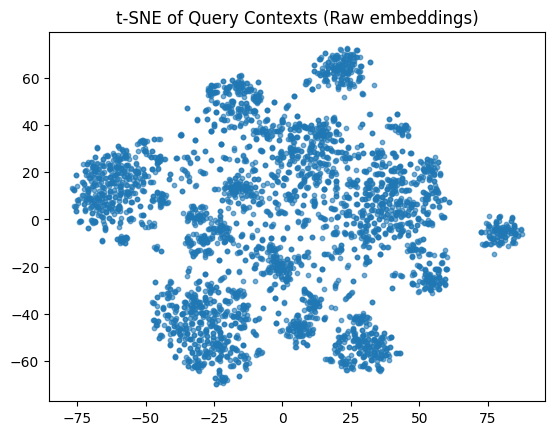

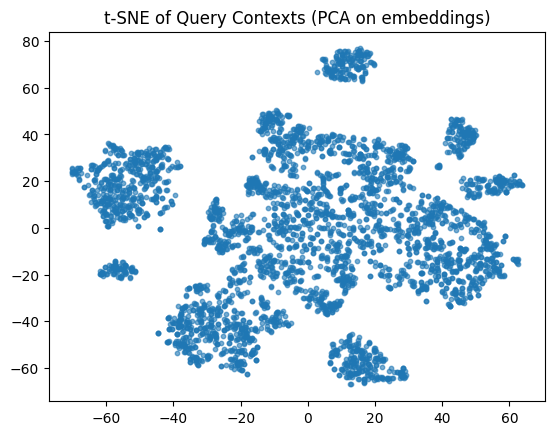

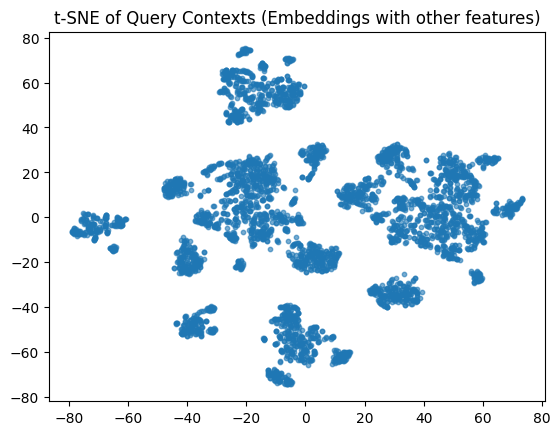

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


tsne = TSNE(n_components=2)
raw_contexts = query_embeddings
proj = tsne.fit_transform(raw_contexts)
plt.scatter(proj[:,0], proj[:,1], s=10, alpha=0.6)
plt.title("t-SNE of Query Contexts (Raw embeddings)")
plt.show()

tsne = TSNE(n_components=2)
raw_contexts = query_embeddings_reduced
proj = tsne.fit_transform(raw_contexts)
plt.scatter(proj[:,0], proj[:,1], s=10, alpha=0.6)
plt.title("t-SNE of Query Contexts (PCA on embeddings)")
plt.show()

#temp_contexts = [get_query_features(q, query_embeddings_reduced[i]) for i, q in enumerate(train_queries)]
#temp_contexts = np.vstack(contexts)
proj = tsne.fit_transform(contexts)
plt.scatter(proj[:,0], proj[:,1], s=10, alpha=0.6)
plt.title("t-SNE of Query Contexts (Embeddings with other features)")
plt.show()


# **PPO (Continuous actions)**

**Hyperparams**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np
import random
from sklearn.decomposition import PCA

# --- Toggle PCA ---
USE_PCA = False
PCA_DIM = 32  # adjust if needed

if USE_PCA:
    pca_ppo = PCA(n_components=PCA_DIM)
    pca_ppo.fit(query_embeddings)
    print(f"PCA applied: reduced from {query_embeddings[0].shape[0]} → {PCA_DIM} dimensions")
else:
    pca_ppo = None

# --- Hyperparameters ---
SET_SIZE = 256
CLIP_EPS = 0.2
PPO_EPOCHS = 5
NUM_UPDATES = 40
LR = 1e-4

TOP_K_VALUES = list(range(1, 11))

**PPO functions**

In [ ]:
def get_query_features_ppo(query, query_embedding):
    if USE_PCA:
        query_embedding = pca_ppo.transform(query_embedding.reshape(1, -1))[0]
    length = len(query.split())
    diversity  = len(set(query.lower().split())) / (length + 1e-5)
    first_word = query.strip().split()[0].lower() if query else ""
    type_flags = [1 if first_word == qtype else 0 for qtype in ["what", "who", "when", "where", "why", "how"]]
    return np.concatenate([query_embedding, [length / 10.0, diversity] + type_flags])

class RetrievalPolicy(nn.Module):
    def __init__(self, input_dim=392, hidden_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.k_head = nn.Linear(hidden_dim, len(TOP_K_VALUES))
        self.lambda_mu = nn.Linear(hidden_dim, 1)
        self.lambda_logstd = nn.Linear(hidden_dim, 1)
        self.tau_mu = nn.Linear(hidden_dim, 1)
        self.tau_logstd = nn.Linear(hidden_dim, 1)

    def forward(self, context_tensor):
        h = self.fc(context_tensor)
        logits_k = self.k_head(h)
        lambda_mu = torch.sigmoid(self.lambda_mu(h))
        lambda_std = F.softplus(self.lambda_logstd(h))
        tau_mu = torch.sigmoid(self.tau_mu(h))
        tau_std = F.softplus(self.tau_logstd(h))
        return logits_k, lambda_mu, lambda_std, tau_mu, tau_std

def sample_action(policy, context_tensor):
    logits_k, lambda_mu, lambda_std, tau_mu, tau_std = policy(context_tensor)
    k_dist = Categorical(logits=logits_k)
    k_idx = k_dist.sample()
    top_k = TOP_K_VALUES[k_idx.item()]
    lambda_val = Normal(lambda_mu, lambda_std).sample().clamp(0, 1).item()
    tau_val = Normal(tau_mu, tau_std).sample().clamp(0.5, 0.8).item()
    log_prob_k = k_dist.log_prob(k_idx)
    return (top_k, lambda_val, tau_val), log_prob_k


def evaluate_single_query(args):
    query, query_embedding, (top_k, lambda_val, tau_val), context_np, log_prob = args
    if USE_PCA:
        query_embedding = pca_ppo.transform(query_embedding.reshape(1, -1))[0]
        doc_reduced = pca_ppo.transform(doc_embeddings)
    else:
        doc_reduced = doc_embeddings

    reward, score, token_cost = evaluate_retrieval(
        query=query,
        top_k=top_k,
        lambda_weight=lambda_val,
        tau=tau_val,
        query_embedding=query_embedding,
        doc_embeddings=doc_reduced,
        doc_idx_map=doc_idx_map
    )
    return context_np, (top_k, lambda_val, tau_val), reward, score, log_prob, token_cost

def collect_batch(policy, train_queries, query_embeddings, num_workers=8):
    args = []
    for i, query in enumerate(train_queries):
        emb = query_embeddings[i]
        context_np = get_query_features(query, emb)
        context_tensor = torch.tensor(context_np, dtype=torch.float32).unsqueeze(0).detach()
        (top_k, lambda_val, tau_val), log_prob = sample_action(policy, context_tensor)
        args.append((query, emb, (top_k, lambda_val, tau_val), context_np, log_prob.item()))

    with Pool(num_workers) as pool:
        results = list(tqdm(pool.imap(evaluate_single_query, args), total=len(args)))

    contexts = [torch.tensor(r[0], dtype=torch.float32) for r in results]
    actions  = [r[1] for r in results]
    rewards  = [r[2] for r in results]
    scores   = [r[3] for r in results]
    log_probs  = [r[4] for r in results]
    token_cost  = [r[5] for r in results]

    return contexts, actions, log_probs, rewards, scores, token_cost

def evaluate_policy_on_validation(policy, val_queries, val_embeddings):
    policy.eval()
    rewards = []
    with torch.no_grad():
        for query, emb in zip(val_queries, val_embeddings):
            context_np = get_query_features_ppo(query, emb)
            context_tensor = torch.tensor(context_np, dtype=torch.float32).unsqueeze(0)

            logits_k, lambda_mu, _, tau_mu, _ = policy(context_tensor)
            top_k = TOP_K_VALUES[torch.argmax(logits_k, dim=-1).item()]
            lambda_val = lambda_mu.item()
            tau_val = tau_mu.item()

            reward, _, token_cost = evaluate_retrieval(
                query=query,
                top_k=top_k,
                lambda_weight=lambda_val,
                tau=tau_val,
                query_embedding=emb,
                doc_embeddings=doc_embeddings,
                doc_idx_map=doc_idx_map
            )
            rewards.append(reward)
    return np.mean(rewards)

def run_ppo_evaluation(test_queries, test_query_embeddings, policy, batch_size=64):
    policy.eval()
    actions = []
    rewards = []
    scores = []
    samples = []
    token_costs = []

    ppo_results = []

    with torch.no_grad():
        for batch_start in tqdm(range(0, len(test_queries), batch_size), desc="Evaluating PPO"):
            batch_end = batch_start + batch_size
            batch_queries = test_queries[batch_start:batch_end]
            batch_embeddings = test_query_embeddings[batch_start:batch_end]

            context_list = [get_query_features_ppo(q, emb) for q, emb in zip(batch_queries, batch_embeddings)]
            context_tensor = torch.tensor(context_list, dtype=torch.float32)

            # Greedy inference
            logits_k, lambda_mu, _, tau_mu, _ = policy(context_tensor)
            k_idx = torch.argmax(logits_k, dim=-1)  # greedy top_k
            top_ks = [TOP_K_VALUES[i.item()] for i in k_idx]

            lambda_vals = lambda_mu.squeeze().tolist()  # mean value
            tau_vals = tau_mu.squeeze().tolist()

            for i in range(len(batch_queries)):
                reward, score, token_cost = evaluate_retrieval(
                    query=batch_queries[i],
                    top_k=top_ks[i],
                    lambda_weight=lambda_vals[i],
                    tau=tau_vals[i],
                    query_embedding=batch_embeddings[i],
                    doc_embeddings=doc_embeddings,
                    doc_idx_map=doc_idx_map
                )

                actions.append((top_ks[i], lambda_vals[i], tau_vals[i]))
                rewards.append(reward)
                scores.append(score)
                token_costs.append(token_cost)

                if len(samples) < 5:
                    samples.append((batch_queries[i], top_ks[i], lambda_vals[i], tau_vals[i], reward))

                ppo_results.append({
                    "agent": "PPO",
                    "query": batch_queries[i],
                    "top_k": top_ks[i],
                    "lambda": lambda_vals[i],
                    "tau": tau_vals[i],
                    "reward": reward,
                    "score": score,
                    "cost": token_cost,
                    "length": len(batch_queries[i].split()),  # Query length
                    "diversity": len(set(batch_queries[i].lower().split())) / (len(batch_queries[i].split()) + 1e-5),
                    "qtype": batch_queries[i].split()[0].lower()  # First word (e.g., what, when, where, etc.)
                })

    print("=== PPO Sample Predictions ===")
    for i, (query, k, lam, tau, reward) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Action → top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}\n")

    print("=== PPO Evaluation Summary ===")
    print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
    print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")
    print(f"→ Avg. Token costs: {np.mean(token_costs):.4f}")

    return np.mean(rewards), np.mean(scores), rewards, actions, token_costs, ppo_results


In [ ]:
# === Initialize PPO ===
dummy_context = get_query_features_ppo(train_queries[0], query_embeddings[0])
input_dim = len(dummy_context)
policy = RetrievalPolicy(input_dim=input_dim)
optimizer = torch.optim.Adam(policy.parameters(), lr=LR)
#initial_weight = 0.05

# storage
ppo_rewards_pre  = []
ppo_rewards_post = []
ppo_results      = []
ppo_rewards_per_update = []


In [ ]:
import random
import numpy as np
import torch
from torch.distributions import Categorical, Normal

# === Hyper-params for clipped PPO ===
EPS_CLIP     = 0.2     # clip ε in [1–ε, 1+ε]
ENTROPY_COEF = 0.01    # weight on entropy bonus

# helper: compute new log-probs *and* batch entropy
def compute_log_probs_and_entropy(policy, contexts_t, actions):
    """
    contexts_t: Tensor [B, D]
    actions:    list of B tuples (top_k, lambda_val, tau_val)
    Returns:
      log_probs: Tensor [B]
      entropy:   scalar Tensor
    """
    # forward pass
    logits_k, lam_mu, lam_std, tau_mu, tau_std = policy(contexts_t)

    # build dists
    dist_k   = Categorical(logits=logits_k)
    dist_lam = Normal(lam_mu, lam_std)
    dist_tau = Normal(tau_mu, tau_std)

    # index / value tensors for the same actions
    k_idxs = torch.tensor(
        [TOP_K_VALUES.index(a[0]) for a in actions],
        dtype=torch.long, device=contexts_t.device
    )
    lam_vals = torch.tensor(
        [a[1] for a in actions],
        dtype=torch.float32, device=contexts_t.device
    ).unsqueeze(-1)
    tau_vals = torch.tensor(
        [a[2] for a in actions],
        dtype=torch.float32, device=contexts_t.device
    ).unsqueeze(-1)

    # log-probs
    lp_k   = dist_k.log_prob(k_idxs)
    lp_lam = dist_lam.log_prob(lam_vals).squeeze(-1)
    lp_tau = dist_tau.log_prob(tau_vals).squeeze(-1)
    log_probs = lp_k + lp_lam + lp_tau

    # entropy bonus
    ent = (
        dist_k.entropy() +
        dist_lam.entropy().squeeze(-1) +
        dist_tau.entropy().squeeze(-1)
    )
    entropy = ent.mean()

    return log_probs, entropy


# === PPO Training Loop (improved) ===
for update in range(NUM_UPDATES):
    print(f"\n=== PPO Iteration {update+1} ===")

    # sample & collect
    idxs = random.sample(range(len(train_queries)), SET_SIZE)
    bq   = [train_queries[i]    for i in idxs]
    be   = [query_embeddings[i] for i in idxs]
    ctxs, acts, lp_old, rews, scores, token_cost = collect_batch(policy, bq, be)
    ctxs_t   = torch.stack(ctxs)                       # [B, D]
    lp_old_t = torch.tensor(lp_old, dtype=torch.float32, device=ctxs_t.device)
    rews_t   = torch.tensor(rews,   dtype=torch.float32, device=ctxs_t.device)

    # compute & normalize advantages
    baseline   = rews_t.mean()
    advantages = rews_t - baseline
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    # record before-update performance
    ppo_rewards_pre.append(baseline.item())

    # PPO epochs
    for epoch in range(PPO_EPOCHS):
        lp_new, entropy = compute_log_probs_and_entropy(policy, ctxs_t, acts)
        ratio = torch.exp(lp_new - lp_old_t)

        # clipped surrogate objective
        unclipped = ratio * advantages
        clipped   = torch.clamp(ratio, 1-EPS_CLIP, 1+EPS_CLIP) * advantages
        clip_loss = torch.min(unclipped, clipped).mean()

        # full loss = –surrogate + entropy bonus
        loss = -clip_loss - ENTROPY_COEF * entropy

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"[Epoch {epoch+1}] Loss: {loss.item():.4f}  Entropy: {entropy.item():.4f}")

    # post-update eval on the same batch
    with torch.no_grad():
        _, _, new_rews, _, _, _ = run_ppo_evaluation(bq, be, policy, batch_size=len(bq))
    ppo_rewards_post.append(np.mean(new_rews))

    # log detailed stats
    ppo_results.append({
        "iteration":  update+1,
        "pre_reward": baseline.item(),
        "post_reward": float(np.mean(new_rews)),
        "avg_score":   float(np.mean(scores)),
        #"avg_cost":   float(np.mean(token_costs)),
    })



=== PPO Iteration 1 ===


100%|██████████| 256/256 [00:05<00:00, 46.94it/s]


[Epoch 1] Loss: 0.2040  Entropy: 4.4855
[Epoch 2] Loss: 0.2038  Entropy: 4.4828
[Epoch 3] Loss: 0.2035  Entropy: 4.4802
[Epoch 4] Loss: 0.2032  Entropy: 4.4775
[Epoch 5] Loss: 0.2030  Entropy: 4.4749


Evaluating PPO: 100%|██████████| 1/1 [00:04<00:00,  4.31s/it]


=== PPO Sample Predictions ===
1. Query: The New York Stock exchange is located where in NYC?
   Action → top_k=3, lambda=0.50, tau=0.50, Reward=0.8677

2. Query: According to Diane McWhorter, every child in the South had to face what?
   Action → top_k=3, lambda=0.50, tau=0.51, Reward=0.9028

3. Query: What fraction of general hospital discharges receive treatment at HHC?
   Action → top_k=3, lambda=0.51, tau=0.51, Reward=0.9143

4. Query: Beyonce, during October 2014, partnered with whom to produce an outdoor line of clothing?
   Action → top_k=5, lambda=0.50, tau=0.51, Reward=0.8598

5. Query: What iPod feature allowed for USB connections with the device?
   Action → top_k=3, lambda=0.50, tau=0.51, Reward=0.8738

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.5593
→ Avg. Relevance Score: 0.6484
→ Avg. Token costs: 148.0859

=== PPO Iteration 2 ===


...

=== PPO Sample Predictions ===
1. Query: When did study of a germ-free-life begin at Notre Dame?
   Action → top_k=3, lambda=0.42, tau=0.65, Reward=0.8722

2. Query: What did the Shanghai Stock Exchange do?
   Action → top_k=3, lambda=0.41, tau=0.68, Reward=0.9303

3. Query: According to article Tibet has remained under what jurisdiction?
   Action → top_k=3, lambda=0.43, tau=0.63, Reward=0.8712

4. Query: The Mrs. Carter Show Limited Edition was released in what year?
   Action → top_k=3, lambda=0.44, tau=0.61, Reward=-0.0094

5. Query: What are the two biggest reasons for resistance?
   Action → top_k=3, lambda=0.44, tau=0.63, Reward=-0.0083

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.6409
→ Avg. Relevance Score: 0.7188
→ Avg. Token costs: 140.4766

=== PPO Iteration 40 ===


100%|██████████| 256/256 [00:05<00:00, 47.40it/s]


[Epoch 1] Loss: 0.0002  Entropy: 3.0402
[Epoch 2] Loss: -0.0005  Entropy: 3.0445
[Epoch 3] Loss: -0.0014  Entropy: 3.0496
[Epoch 4] Loss: -0.0024  Entropy: 3.0553
[Epoch 5] Loss: -0.0035  Entropy: 3.0614


Evaluating PPO: 100%|██████████| 1/1 [00:04<00:00,  4.22s/it]

=== PPO Sample Predictions ===
1. Query: What fraction of emergency room visits receive treatment at HHC?
   Action → top_k=3, lambda=0.42, tau=0.66, Reward=0.9219

2. Query: Which Apple technology did Pat-rights complain breached their patent in a lawsuit?
   Action → top_k=3, lambda=0.43, tau=0.64, Reward=0.8807

3. Query: How many school children died due to shoddy construction?
   Action → top_k=3, lambda=0.41, tau=0.68, Reward=0.8947

4. Query: Who did Chopin last perform with?
   Action → top_k=3, lambda=0.41, tau=0.66, Reward=0.9069

5. Query: The placement of deciduous trees on the Equator facing side of a building can have a negative effect on solar availability in which season?
   Action → top_k=3, lambda=0.42, tau=0.66, Reward=0.8665

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.6683
→ Avg. Relevance Score: 0.7461
→ Avg. Token costs: 140.3086


# **Old PPO training loop (Ignore)**

In [ ]:
# # === PPO Training Loop ===
# for update in range(NUM_UPDATES):
#     print(f"\n=== PPO Iteration {update + 1} ===")
#     sampled_indices = random.sample(range(len(train_queries)), SET_SIZE)
#     batch_queries = [train_queries[i] for i in sampled_indices]
#     batch_embeddings = [query_embeddings[i] for i in sampled_indices]

#     contexts, actions, log_probs_old, rewards, scores = collect_batch(policy, batch_queries, batch_embeddings)
#     contexts_tensor = torch.stack(contexts)
#     log_probs_old_tensor = torch.tensor(log_probs_old, dtype=torch.float32)
#     rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
#     baseline = rewards_tensor.mean()
#     advantages = rewards_tensor - baseline

#     # Record the batch's avg reward BEFORE optimization
#     avg_reward = rewards_tensor.mean().item()
#     ppo_rewards_per_update.append(avg_reward)

#     for epoch in range(PPO_EPOCHS):
#         logits_k, lambda_mu, lambda_std, tau_mu, tau_std = policy(contexts_tensor)

#         entropy_k = Categorical(logits=logits_k).entropy()
#         entropy_lambda = Normal(lambda_mu, lambda_std).entropy().squeeze()
#         entropy_tau = Normal(tau_mu, tau_std).entropy().squeeze()
#         '''log_probs_new = []
#         for i, action in enumerate(actions):
#             top_k, lambda_val, tau_val = action
#             k_idx = torch.tensor(TOP_K_VALUES.index(top_k)).to(contexts_tensor.device)
#             log_prob_k = Categorical(logits=logits_k[i]).log_prob(k_idx)
#             log_prob_lambda = Normal(lambda_mu[i], lambda_std[i]).log_prob(torch.tensor(lambda_val)).squeeze()
#             log_prob_tau = Normal(tau_mu[i], tau_std[i]).log_prob(torch.tensor(tau_val)).squeeze()
#             log_probs_new.append(log_prob_k + log_prob_lambda + log_prob_tau)

#         log_probs_new_tensor = torch.stack(log_probs_new)'''
#         # Vectorized top_k log-prob
#         k_indices = torch.tensor([TOP_K_VALUES.index(a[0]) for a in actions]).to(contexts_tensor.device)
#         log_probs_k = Categorical(logits=logits_k).log_prob(k_indices)

#         # Vectorized lambda and tau log-probs
#         log_probs_lambda = torch.stack([
#             Normal(lambda_mu[i], lambda_std[i]).log_prob(torch.tensor(a[1])).squeeze()
#             for i, a in enumerate(actions)
#         ])

#         log_probs_tau = torch.stack([
#             Normal(tau_mu[i], tau_std[i]).log_prob(torch.tensor(a[2])).squeeze()
#             for i, a in enumerate(actions)
#         ])

#         # Combine all log-probs
#         log_probs_new_tensor = log_probs_k + log_probs_lambda + log_probs_tau

#         ratios = torch.exp(log_probs_new_tensor - log_probs_old_tensor)
#         clip_loss = torch.min(ratios * advantages, torch.clamp(ratios, 1 - CLIP_EPS, 1 + CLIP_EPS) * advantages)
#         entropy = entropy_k.mean() + entropy_lambda.mean() + entropy_tau.mean()

#         #entropy_weight = initial_weight * (1 - update / NUM_UPDATES)
#         #loss = -clip_loss.mean() - entropy_weight * entropy
#         loss = -clip_loss.mean() - 0.01 * entropy

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         #print("logits_k (first 5):", logits_k[:5].detach().cpu().numpy())

#         print(f"[Epoch {epoch + 1}] PPO Loss: {loss.item():.4f}")
#         print(f"  → Entropy_k: {entropy_k.mean().item():.2f}, lambda: {entropy_lambda.mean().item():.2f}, tau: {entropy_tau.mean().item():.2f}")

#     print(f"→ Avg. Reward: {rewards_tensor.mean():.4f}")
#     print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")
#     #val_reward = evaluate_policy_on_validation(policy, val_queries, val_embeddings) # Run validatoin on a separate set
#     #ppo_rewards_per_update.append(val_reward)
#     #print(f"→ Val Reward: {val_reward:.4f}")

#     # === Logging per query (match order in batch_queries) ===
#     for i, query in enumerate(batch_queries):
#         top_k, lambda_val, tau_val = actions[i]
#         reward = rewards[i]
#         relevance_score = scores[i]

#         # Recompute context features
#         query_embedding = batch_embeddings[i]
#         query_features = get_query_features(query, query_embedding)
#         length = query_features[-8]
#         entropy_val = query_features[-7]
#         qtype = query.strip().split()[0].lower() if query else "unknown"

#         # Estimate cost from evaluate_retrieval if needed
#         filtered_docs = hybrid_retrieve(query, top_k, lambda_val,
#                                         query_embedding=query_embedding,
#                                         doc_embeddings=doc_embeddings,
#                                         doc_idx_map=doc_idx_map)
#         token_cost = sum(len(doc.split()) for doc in filtered_docs)

#       #  ppo_results.append({
#       #       "agent": "PPO",
#       #       "query": query,
#       #       "top_k": top_k,
#       #       "lambda": lambda_val,
#       #       "tau": tau_val,
#       #       "reward": reward,
#       #       "score": relevance_score,
#       #       "cost": token_cost,
#       #       "length": length,
#       #       "entropy": entropy_val,
#       #       "qtype": qtype
#       #   })





=== PPO Iteration 1 ===


100%|██████████| 256/256 [00:06<00:00, 40.19it/s]


[Epoch 1] PPO Loss: 0.0712
  → Entropy_k: 2.30, lambda: 1.16, tau: 1.07
[Epoch 2] PPO Loss: 0.0710
  → Entropy_k: 2.30, lambda: 1.16, tau: 1.07
[Epoch 3] PPO Loss: 0.0709
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.07
[Epoch 4] PPO Loss: 0.0708
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 5] PPO Loss: 0.0707
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
→ Avg. Reward: 0.6450
→ Avg. Relevance Score: 0.6758

=== PPO Iteration 2 ===


100%|██████████| 256/256 [00:05<00:00, 43.07it/s]


[Epoch 1] PPO Loss: 0.0753
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 2] PPO Loss: 0.0752
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 3] PPO Loss: 0.0751
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.06
[Epoch 4] PPO Loss: 0.0750
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.05
[Epoch 5] PPO Loss: 0.0749
  → Entropy_k: 2.30, lambda: 1.15, tau: 1.05
→ Avg. Reward: 0.6233
→ Avg. Relevance Score: 0.6523

=== PPO Iteration 3 ===


...

[Epoch 1] PPO Loss: -0.0117
  → Entropy_k: 2.29, lambda: 0.74, tau: 0.24
[Epoch 2] PPO Loss: -0.0130
  → Entropy_k: 2.29, lambda: 0.73, tau: 0.22
[Epoch 3] PPO Loss: -0.0142
  → Entropy_k: 2.29, lambda: 0.72, tau: 0.20
[Epoch 4] PPO Loss: -0.0153
  → Entropy_k: 2.29, lambda: 0.71, tau: 0.19
[Epoch 5] PPO Loss: -0.0163
  → Entropy_k: 2.29, lambda: 0.71, tau: 0.17
→ Avg. Reward: 0.6251
→ Avg. Relevance Score: 0.6523

=== PPO Iteration 29 ===


100%|██████████| 256/256 [00:05<00:00, 44.14it/s]


[Epoch 1] PPO Loss: -0.0162
  → Entropy_k: 2.29, lambda: 0.70, tau: 0.15
[Epoch 2] PPO Loss: -0.0167
  → Entropy_k: 2.29, lambda: 0.69, tau: 0.13
[Epoch 3] PPO Loss: -0.0173
  → Entropy_k: 2.29, lambda: 0.69, tau: 0.12
[Epoch 4] PPO Loss: -0.0178
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.10
[Epoch 5] PPO Loss: -0.0185
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.09
→ Avg. Reward: 0.6430
→ Avg. Relevance Score: 0.6719

=== PPO Iteration 30 ===


100%|██████████| 256/256 [00:05<00:00, 43.85it/s]


[Epoch 1] PPO Loss: -0.0260
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.08
[Epoch 2] PPO Loss: -0.0259
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.07
[Epoch 3] PPO Loss: -0.0259
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.06
[Epoch 4] PPO Loss: -0.0260
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.05
[Epoch 5] PPO Loss: -0.0263
  → Entropy_k: 2.29, lambda: 0.68, tau: 0.04
→ Avg. Reward: 0.7023
→ Avg. Relevance Score: 0.7344


# **Plots**

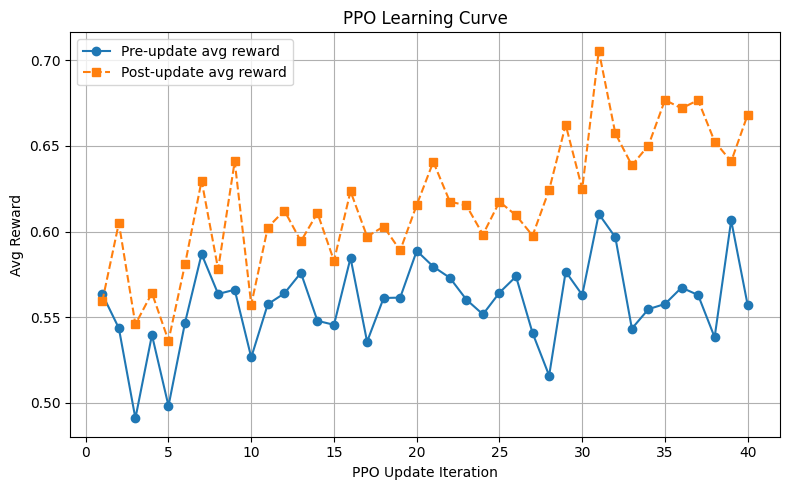

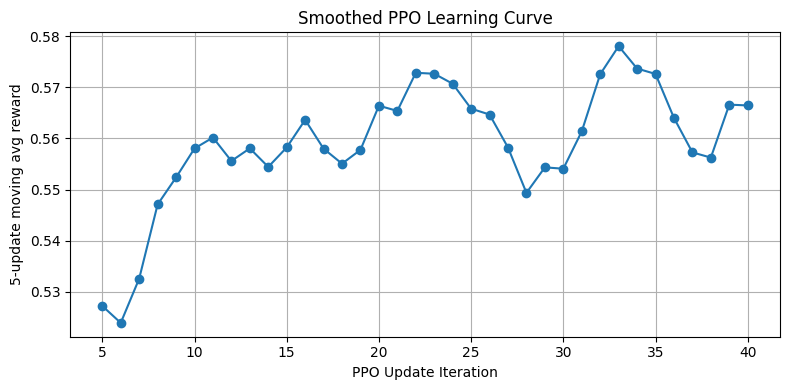

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1) PPO Learning Curve (pre‐ vs. post‐update) ---
updates = np.arange(1, len(ppo_rewards_pre) + 1)

plt.figure(figsize=(8, 5))
plt.plot(updates, ppo_rewards_pre,  marker='o', linestyle='-', label='Pre‐update avg reward')
plt.plot(updates, ppo_rewards_post, marker='s', linestyle='--', label='Post‐update avg reward')
plt.xlabel('PPO Update Iteration')
plt.ylabel('Avg Reward')
plt.title('PPO Learning Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# (Optional) Smoothing
def moving_average(x, window=5):
    return np.convolve(x, np.ones(window)/window, mode='valid')

window = 5
smoothed = moving_average(ppo_rewards_pre, window)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(window, len(ppo_rewards_pre)+1), smoothed, marker='o')
plt.xlabel('PPO Update Iteration')
plt.ylabel(f'{window}-update moving avg reward')
plt.title('Smoothed PPO Learning Curve')
plt.grid(True)
plt.tight_layout()
plt.show()


# # --- 2) Reward Distribution Across Methods ---
# # Make sure you’ve already populated these via:
# #   mab_avg, _, mab_rewards, _    = run_noncontextual_mab_evaluation(...)
# #   cmab_avg, _, cmab_rewards, _  = run_cmab_evaluation(...)
# #   ppo_avg, _, ppo_rewards, _    = run_ppo_evaluation(...)
# data   = [mab_rewards, cmab_rewards, ppo_rewards]
# labels = ['Non-Contextual MAB', 'Contextual MAB', 'PPO']

# plt.figure(figsize=(8, 6))
# plt.boxplot(data, labels=labels)
# plt.title('Reward Distribution Across Methods')
# plt.ylabel('Reward')
# plt.grid(True, axis='y')
# plt.tight_layout()
# # make y lable more concise
# plt.ylim(0.9, 1.0)
# plt.show()


# **A2C**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical, Normal

TOP_K_VALUES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

class RetrievalActorCritic(nn.Module):
    def __init__(self, input_dim=392, hidden_dim=128):
        super().__init__()
        # Shared backbone
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        # Actor heads
        self.k_head = nn.Linear(hidden_dim, len(TOP_K_VALUES))
        self.lambda_mu = nn.Linear(hidden_dim, 1)
        self.lambda_logstd = nn.Linear(hidden_dim, 1)
        self.tau_mu = nn.Linear(hidden_dim, 1)
        self.tau_logstd = nn.Linear(hidden_dim, 1)

        # Critic head
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, context_tensor):
        h = self.fc(context_tensor)
        # Actor outputs
        logits_k = self.k_head(h)
        lambda_mu = torch.sigmoid(self.lambda_mu(h))
        lambda_std = F.softplus(self.lambda_logstd(h))
        tau_mu = torch.sigmoid(self.tau_mu(h))
        tau_std = F.softplus(self.tau_logstd(h))
        # Critic output
        value = self.value_head(h)
        return logits_k, lambda_mu, lambda_std, tau_mu, tau_std, value


In [ ]:
# Initialize
model = RetrievalActorCritic(input_dim=len(get_query_features(train_queries[0], query_embeddings[0])))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Hyperparameters
SET_SIZE = 256
NUM_UPDATES = 30

# A2C Loop
for update in range(NUM_UPDATES):
    print(f"\n=== A2C Iteration {update + 1} ===")

    sampled_indices = random.sample(range(len(train_queries)), SET_SIZE)
    batch_queries = [train_queries[i] for i in sampled_indices]
    batch_embeddings = [query_embeddings[i] for i in sampled_indices]

    contexts = [get_query_features(q, emb) for q, emb in zip(batch_queries, batch_embeddings)]
    context_tensor = torch.tensor(contexts, dtype=torch.float32)

    logits_k, lambda_mu, lambda_std, tau_mu, tau_std, values = model(context_tensor)

    actions = []
    log_probs = []
    rewards = []
    entropies = []

    for i in range(len(batch_queries)):
        # Sample actions
        k_dist = Categorical(logits=logits_k[i])
        k_idx = k_dist.sample()
        top_k = TOP_K_VALUES[k_idx.item()]
        lambda_val = Normal(lambda_mu[i], lambda_std[i]).sample().clamp(0, 1).item()
        tau_val = Normal(tau_mu[i], tau_std[i]).sample().clamp(0.5, 0.8).item()

        # Log-prob
        log_prob = k_dist.log_prob(k_idx) \
                 + Normal(lambda_mu[i], lambda_std[i]).log_prob(torch.tensor(lambda_val)).squeeze() \
                 + Normal(tau_mu[i], tau_std[i]).log_prob(torch.tensor(tau_val)).squeeze()

        # Entropy
        entropy = k_dist.entropy() + Normal(lambda_mu[i], lambda_std[i]).entropy().squeeze() + Normal(tau_mu[i], tau_std[i]).entropy().squeeze()

        # Evaluate action
        reward, _, token_cost = evaluate_retrieval(
            query=batch_queries[i],
            top_k=top_k,
            lambda_weight=lambda_val,
            tau=tau_val,
            query_embedding=batch_embeddings[i],
            doc_embeddings=doc_embeddings,
            doc_idx_map=doc_idx_map
        )

        actions.append((top_k, lambda_val, tau_val))
        log_probs.append(log_prob)
        rewards.append(reward)
        entropies.append(entropy)

    # Prepare tensors
    log_probs_tensor = torch.stack(log_probs)
    rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
    values_tensor = values.squeeze()

    # Advantage
    advantages = rewards_tensor - values_tensor.detach()

    # A2C Loss
    actor_loss = -(log_probs_tensor * advantages).mean()
    critic_loss = F.mse_loss(values_tensor, rewards_tensor)
    entropy_bonus = torch.stack(entropies).mean()

    total_loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy_bonus

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    print(f"Total Loss: {total_loss.item():.4f} | Actor: {actor_loss.item():.4f} | Critic: {critic_loss.item():.4f} | Entropy: {entropy_bonus.item():.2f}")



=== A2C Iteration 1 ===
Total Loss: 1.7264 | Actor: 1.5920 | Critic: 0.3581 | Entropy: 4.47

=== A2C Iteration 2 ===
Total Loss: 2.0464 | Actor: 1.8847 | Critic: 0.4129 | Entropy: 4.47

=== A2C Iteration 3 ===
Total Loss: 1.8157 | Actor: 1.6750 | Critic: 0.3708 | Entropy: 4.47

=== A2C Iteration 4 ===
Total Loss: 1.8724 | Actor: 1.7282 | Critic: 0.3778 | Entropy: 4.47

=== A2C Iteration 5 ===
Total Loss: 1.7523 | Actor: 1.6159 | Critic: 0.3622 | Entropy: 4.47

=== A2C Iteration 6 ===
Total Loss: 1.7296 | Actor: 1.5919 | Critic: 0.3647 | Entropy: 4.46

=== A2C Iteration 7 ===
Total Loss: 1.7672 | Actor: 1.6310 | Critic: 0.3616 | Entropy: 4.46

=== A2C Iteration 8 ===
Total Loss: 1.9893 | Actor: 1.8324 | Critic: 0.4031 | Entropy: 4.46

=== A2C Iteration 9 ===
Total Loss: 1.6913 | Actor: 1.5597 | Critic: 0.3524 | Entropy: 4.46

=== A2C Iteration 10 ===
Total Loss: 1.7814 | Actor: 1.6420 | Critic: 0.3679 | Entropy: 4.46

=== A2C Iteration 11 ===
Total Loss: 1.8140 | Actor: 1.6732 | Critic

# **Evaluation**

In [ ]:
test_queries = random.sample(questions, TEST_SIZE)

print("Encoding test queries (batched)...")
test_query_embeddings = []

for i in tqdm(range(0, len(test_queries), encode_batch_size), desc="Test Queries"):
    batch = test_queries[i:i+encode_batch_size]
    embs = dense_model.encode(batch, normalize_embeddings=True)
    test_query_embeddings.append(embs)

test_query_embeddings = np.vstack(test_query_embeddings)


Encoding test queries (batched)...


Test Queries: 100%|██████████| 10/10 [00:00<00:00, 72.80it/s]


# **Non-Contextual MAB Test**

In [ ]:
from collections import Counter

def run_noncontextual_mab_evaluation(test_queries, mab_model, action_map):
    rewards = []
    scores = []
    actions = []
    samples = []
    token_costs= []

    for query in test_queries:
        action_id = mab_model.predict()
        top_k, lambda_val, tau_val = action_map[action_id]

        reward, score, token_cost = evaluate_retrieval(
            query,
            top_k=top_k,
            lambda_weight=lambda_val,
            tau=tau_val,
            query_embedding=None,  # non-contextual retrieval
            doc_embeddings=doc_embeddings,
            doc_idx_map=doc_idx_map
        )

        rewards.append(reward)
        scores.append(score)
        actions.append(action_id)
        token_costs.append(token_cost)

        if len(samples) < 5:
            samples.append((query, top_k, lambda_val, tau_val, reward, token_cost))

    avg_reward = np.mean(rewards)
    avg_score = np.mean(scores)
    action_distribution = Counter(actions)
    avg_cost = np.mean(token_costs)

    # Display Results
    print("=== Non-Contextual MAB Sample Predictions ===")
    for i, (query, k, lam, tau, reward, token_cost) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Selected Action: top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}, token costs={token_cost}\n")

    print("=== Non-Contextual MAB Evaluation Summary ===")
    print(f"→ Avg. Reward: {avg_reward:.4f}")
    print(f"→ Avg. Relevance Score: {avg_score:.4f}")
    print(f"→ Avg. Token cost: {avg_cost:.4f}")
    print("→ Action Distribution:")
    for action_id, count in action_distribution.items():
        k, lam, tau = action_map[action_id]
        print(f"  Index {action_id} → top_k={k}, lambda={lam}, tau={tau} (count={count})")

    return avg_reward, avg_score, rewards, actions, token_costs

mab_reward, mab_score, mab_rewards, mab_actions, mab_token_costs = run_noncontextual_mab_evaluation(
    test_queries,
    mab_model=mab,
    action_map=action_map
)

=== Non-Contextual MAB Sample Predictions ===
1. Query: What former Bond theme singer was the subject of extensive activity on Twitter when the Spectre theme was released?
   Selected Action: top_k=1, lambda=0.30, tau=0.80, Reward=0.9625, token costs=74

2. Query: Why are antibiotics checked before use?
   Selected Action: top_k=1, lambda=0.30, tau=0.80, Reward=0.0000, token costs=0

3. Query: The decrease in crime in New York is sometimes attributed to the decline of what street drug?
   Selected Action: top_k=5, lambda=1.00, tau=0.55, Reward=-0.0125, token costs=0

4. Query: In front of which committee did Powell testify?
   Selected Action: top_k=1, lambda=0.30, tau=0.80, Reward=0.9600, token costs=79

5. Query: What common drug can reduce antibiotic effectiveness?
   Selected Action: top_k=1, lambda=0.30, tau=0.80, Reward=0.0000, token costs=0

=== Non-Contextual MAB Evaluation Summary ===
→ Avg. Reward: 0.5817
→ Avg. Relevance Score: 0.6067
→ Avg. Token cost: 48.9033
→ Action Dist

# **Contextual MAB Test**

In [ ]:
from collections import Counter

def run_cmab_evaluation(test_queries, test_query_embeddings, cmab_model, action_map, pca=None):
    rewards = []
    scores = []
    actions = []
    samples = []
    token_costs= []

    for i, query in enumerate(test_queries):
        query_embedding = test_query_embeddings[i]

        # Apply PCA if provided
        if pca is not None:
            query_embedding = pca.transform([query_embedding])[0]

        context = get_query_features(query, query_embedding).reshape(1, -1)
        action_id = cmab_model.predict(context)
        top_k, lambda_val, tau_val = action_map[action_id]

        reward, score, token_cost = evaluate_retrieval(
            query=query,
            top_k=top_k,
            lambda_weight=lambda_val,
            tau=tau_val,
            query_embedding=test_query_embeddings[i],  # full dim for retrieval
            doc_embeddings=doc_embeddings,
            doc_idx_map=doc_idx_map
        )

        rewards.append(reward)
        scores.append(score)
        actions.append(action_id)
        token_costs.append(token_cost)

        if len(samples) < 5:
            samples.append((query, top_k, lambda_val, tau_val, reward, token_cost))

    avg_reward = np.mean(rewards)
    avg_score = np.mean(scores)
    avg_cost = np.mean(token_costs)
    action_distribution = Counter(actions)

    # Display Results
    print("=== Contextual MAB Sample Predictions ===")
    for i, (query, k, lam, tau, reward, token_cost) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Selected Action: top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}, token cost={token_cost}\n")

    print("=== Contextual MAB Evaluation Summary ===")
    print(f"→ Avg. Reward: {avg_reward:.4f}")
    print(f"→ Avg. Relevance Score: {avg_score:.4f}")
    print(f"→ Avg. Token cost: {avg_cost:.4f}")
    print("→ Action Distribution:")
    for action_id, count in action_distribution.items():
        k, lam, tau = action_map[action_id]
        print(f"  Index {action_id} → top_k={k}, lambda={lam}, tau={tau} (count={count})")

    return avg_reward, avg_score, rewards, actions, token_costs

# Run CMAB Evaluation
cmab_reward, cmab_score, cmab_rewards, cmab_actions, cmab_token_costs  = run_cmab_evaluation(
    test_queries, test_query_embeddings,
    cmab_model=contextual_mab,
    action_map=action_map,
    pca=pca_cmab  # or None if not using PCA
)


=== Contextual MAB Sample Predictions ===
1. Query: What former Bond theme singer was the subject of extensive activity on Twitter when the Spectre theme was released?
   Selected Action: top_k=5, lambda=0.00, tau=0.70, Reward=0.8095, token cost=370

2. Query: Why are antibiotics checked before use?
   Selected Action: top_k=1, lambda=0.20, tau=0.50, Reward=-0.0150, token cost=0

3. Query: The decrease in crime in New York is sometimes attributed to the decline of what street drug?
   Selected Action: top_k=5, lambda=0.00, tau=0.70, Reward=-0.0050, token cost=0

4. Query: In front of which committee did Powell testify?
   Selected Action: top_k=5, lambda=0.00, tau=0.70, Reward=0.7970, token cost=395

5. Query: What common drug can reduce antibiotic effectiveness?
   Selected Action: top_k=2, lambda=0.40, tau=0.50, Reward=0.9510, token cost=67

=== Contextual MAB Evaluation Summary ===
→ Avg. Reward: 0.5456
→ Avg. Relevance Score: 0.6333
→ Avg. Token cost: 158.7167
→ Action Distribution

# **PPO Test**

In [ ]:
from tqdm import tqdm


# Run PPO Evaluation
ppo_reward, ppo_score, ppo_rewards, ppo_actions, ppo_token_costs, ppo_test_results = run_ppo_evaluation(test_queries, test_query_embeddings, policy)

Evaluating PPO: 100%|██████████| 5/5 [00:05<00:00,  1.06s/it]

=== PPO Sample Predictions ===
1. Query: What former Bond theme singer was the subject of extensive activity on Twitter when the Spectre theme was released?
   Action → top_k=3, lambda=0.43, tau=0.64, Reward=0.8803

2. Query: Why are antibiotics checked before use?
   Action → top_k=3, lambda=0.45, tau=0.60, Reward=0.9145

3. Query: The decrease in crime in New York is sometimes attributed to the decline of what street drug?
   Action → top_k=3, lambda=0.41, tau=0.66, Reward=-0.0068

4. Query: In front of which committee did Powell testify?
   Action → top_k=3, lambda=0.43, tau=0.63, Reward=0.8723

5. Query: What common drug can reduce antibiotic effectiveness?
   Action → top_k=3, lambda=0.44, tau=0.63, Reward=0.9238

=== PPO Evaluation Summary ===
→ Avg. Reward: 0.6345
→ Avg. Relevance Score: 0.7100
→ Avg. Token costs: 135.5033


# **A2C Test**

In [ ]:
from tqdm import tqdm

def run_a2c_evaluation(test_queries, test_query_embeddings, model, batch_size=64):
    model.eval()
    actions = []
    rewards = []
    scores = []
    samples = []
    a2c_results = []
    token_costs = []

    with torch.no_grad():
        for batch_start in tqdm(range(0, len(test_queries), batch_size), desc="Evaluating A2C"):
            batch_end = batch_start + batch_size
            batch_queries = test_queries[batch_start:batch_end]
            batch_embeddings = test_query_embeddings[batch_start:batch_end]

            context_list = [get_query_features(q, emb) for q, emb in zip(batch_queries, batch_embeddings)]
            context_tensor = torch.tensor(context_list, dtype=torch.float32)

            # Greedy inference
            logits_k, lambda_mu, _, tau_mu, _, _ = model(context_tensor)
            k_idx = torch.argmax(logits_k, dim=-1)  # deterministic top_k choice
            top_ks = [TOP_K_VALUES[i.item()] for i in k_idx]

            lambda_vals = lambda_mu.squeeze().tolist()  # take mean
            tau_vals = tau_mu.squeeze().tolist()        # take mean

            for i in range(len(batch_queries)):
                reward, score, token_cost = evaluate_retrieval(
                    query=batch_queries[i],
                    top_k=top_ks[i],
                    lambda_weight=lambda_vals[i],
                    tau=tau_vals[i],
                    query_embedding=batch_embeddings[i],
                    doc_embeddings=doc_embeddings,
                    doc_idx_map=doc_idx_map
                )

                actions.append((top_ks[i], lambda_vals[i], tau_vals[i]))
                rewards.append(reward)
                scores.append(score)
                token_costs.append(token_cost)

                if len(samples) < 5:
                    samples.append((batch_queries[i], top_ks[i], lambda_vals[i], tau_vals[i], reward))


                a2c_results.append({
                    "agent": "A2C",
                    "query": batch_queries[i],
                    "top_k": top_ks[i],
                    "lambda": lambda_vals[i],
                    "tau": tau_vals[i],
                    "reward": reward,
                    "score": score,
                    "cost": token_cost,
                    "length": len(batch_queries[i].split()),  # Query length
                    "diversity": len(set(batch_queries[i].lower().split())) / (len(batch_queries[i].split()) + 1e-5),
                    "qtype": batch_queries[i].split()[0].lower()  # First word (e.g., what, when, where, etc.)
                })

    print("=== A2C Sample Predictions ===")
    for i, (query, k, lam, tau, reward) in enumerate(samples, 1):
        print(f"{i}. Query: {query}")
        print(f"   Action → top_k={k}, lambda={lam:.2f}, tau={tau:.2f}, Reward={reward:.4f}\n")


    print("=== A2C Evaluation Summary ===")
    print(f"→ Avg. Reward: {np.mean(rewards):.4f}")
    print(f"→ Avg. Relevance Score: {np.mean(scores):.4f}")
    print(f"→ Avg. Token cost: {np.mean(token_costs):.4f}")


    return np.mean(rewards), np.mean(scores), rewards, actions, a2c_results

# --- Run A2C Evaluation ---
a2c_reward, a2c_score, a2c_rewards, a2c_actions, a2c_test_results  = run_a2c_evaluation(test_queries, test_query_embeddings, model)


Evaluating A2C: 100%|██████████| 5/5 [00:04<00:00,  1.01it/s]

=== A2C Sample Predictions ===
1. Query: What former Bond theme singer was the subject of extensive activity on Twitter when the Spectre theme was released?
   Action → top_k=9, lambda=0.50, tau=0.53, Reward=0.7268

2. Query: Why are antibiotics checked before use?
   Action → top_k=9, lambda=0.50, tau=0.53, Reward=0.6483

3. Query: The decrease in crime in New York is sometimes attributed to the decline of what street drug?
   Action → top_k=9, lambda=0.50, tau=0.53, Reward=0.9108

4. Query: In front of which committee did Powell testify?
   Action → top_k=9, lambda=0.50, tau=0.53, Reward=0.7883

5. Query: What common drug can reduce antibiotic effectiveness?
   Action → top_k=9, lambda=0.50, tau=0.52, Reward=0.7177

=== A2C Evaluation Summary ===
→ Avg. Reward: 0.5868
→ Avg. Relevance Score: 0.7567
→ Avg. Token cost: 311.5900


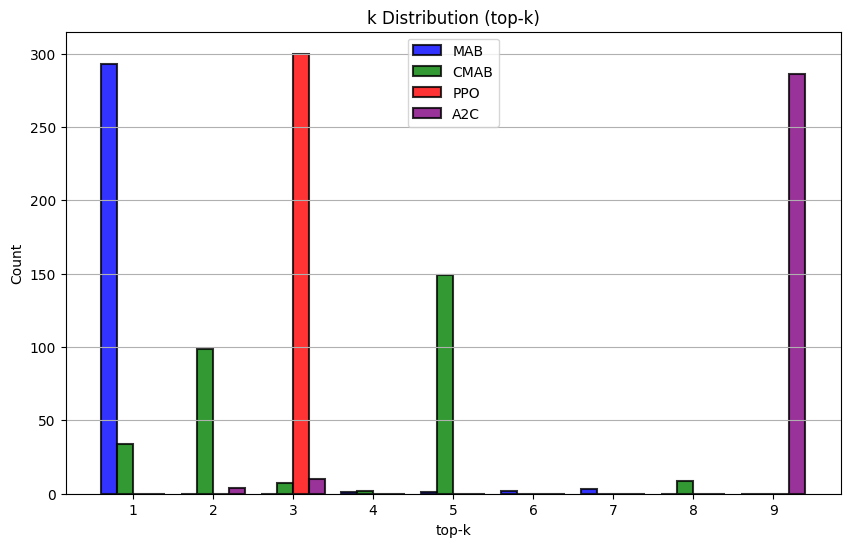

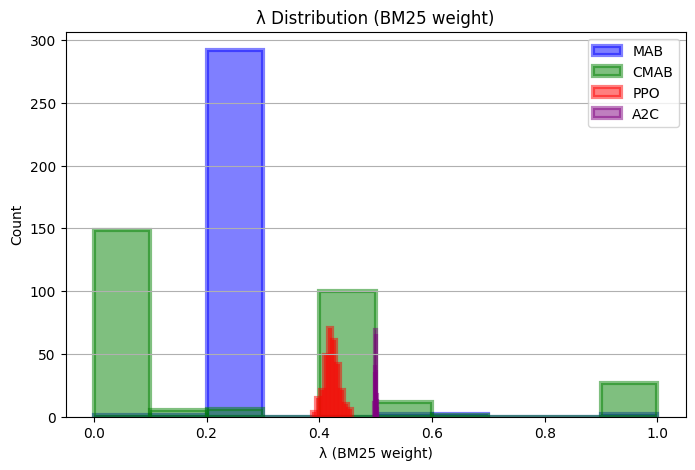

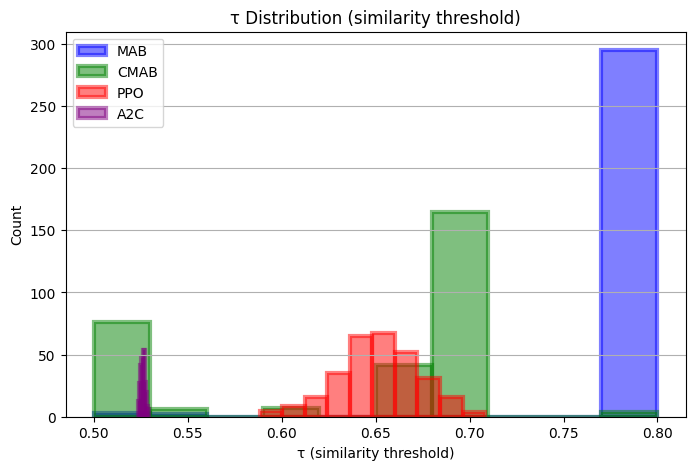

In [ ]:
import matplotlib.pyplot as plt


# Decode MAB and CMAB to (k, λ, τ)
mab_action_values = [action_map[idx] for idx in mab_actions]
cmab_action_values = [action_map[idx] for idx in cmab_actions]

# Separate each component
def unpack_components(actions):
    ks, lambdas, taus = zip(*actions)
    return ks, lambdas, taus

mab_k, mab_lambda, mab_tau = unpack_components(mab_action_values)
cmab_k, cmab_lambda, cmab_tau = unpack_components(cmab_action_values)
ppo_k, ppo_lambda, ppo_tau = unpack_components(ppo_actions)
a2c_k, a2c_lambda, a2c_tau = unpack_components(a2c_actions)

# Function to plot
def plot_k(distributions, labels, title, xlabel, colors=None):
    plt.figure(figsize=(10, 6))

    if colors is None:
        colors = ["blue", "green", "red", "purple"]

    # Get all unique k values
    unique_ks = sorted(set(k for dist in distributions for k in dist))

    x = np.arange(len(unique_ks))  # positions on x-axis
    width = 0.2  # width of each bar

    for i, (dist, label, color) in enumerate(zip(distributions, labels, colors)):
        # Count occurrences of each k
        counts = [dist.count(k) for k in unique_ks]
        plt.bar(
            x + i * width,         # Shift bars for each distribution
            counts,
            width=width,
            label=label,
            color=color,
            edgecolor="black",     # black outlines!
            linewidth=1.5,
            alpha=0.8
        )

    plt.xticks(x + width * (len(distributions) - 1) / 2, unique_ks)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, axis='y')
    plt.show()

def plot_component(distributions, labels, bins, title, xlabel, colors=None):
    plt.figure(figsize=(8, 5))

    if colors is None:
        # Default colors if not provided
        colors = ["blue", "green", "red", "purple"]

    for dist, label, color in zip(distributions, labels, colors):
        plt.hist(
            dist,
            bins=bins,
            label=label,
            rwidth=1.5,
            histtype="bar",
            alpha=0.5,
            align='mid',
            color=color,          # fill color
            edgecolor=color,      # outline color (same as fill)
            linewidth=3         # add thick edge
        )

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, axis='y')
    plt.show()


# Now Plot Separately
plot_k(
    distributions=[mab_k, cmab_k, ppo_k, a2c_k],
    labels=["MAB", "CMAB", "PPO", "A2C"],
    title="k Distribution (top-k)",
    xlabel="top-k"
)

plot_component(
    distributions=[mab_lambda, cmab_lambda, ppo_lambda, a2c_lambda],
    labels=["MAB", "CMAB", "PPO", "A2C"],
    bins=10,
    title="λ Distribution (BM25 weight)",
    xlabel="λ (BM25 weight)"
)

plot_component(
    distributions=[mab_tau, cmab_tau, ppo_tau, a2c_tau],
    labels=["MAB", "CMAB", "PPO", "A2C"],
    bins=10,
    title="τ Distribution (similarity threshold)",
    xlabel="τ (similarity threshold)"
)





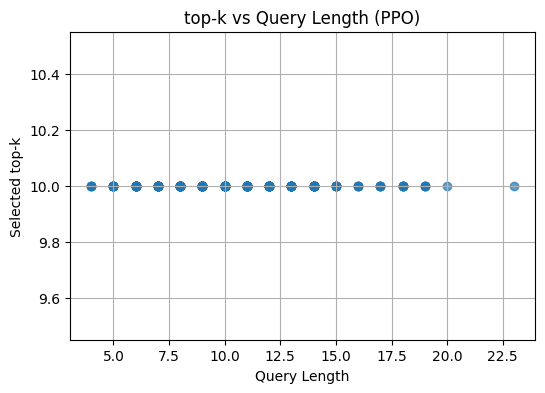

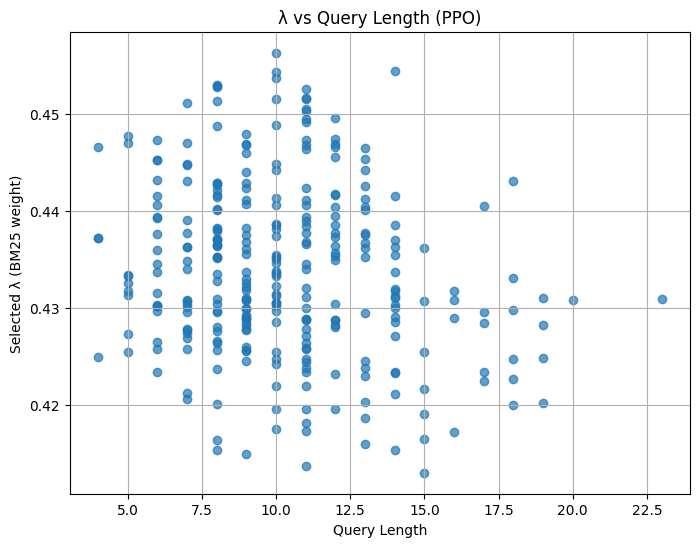

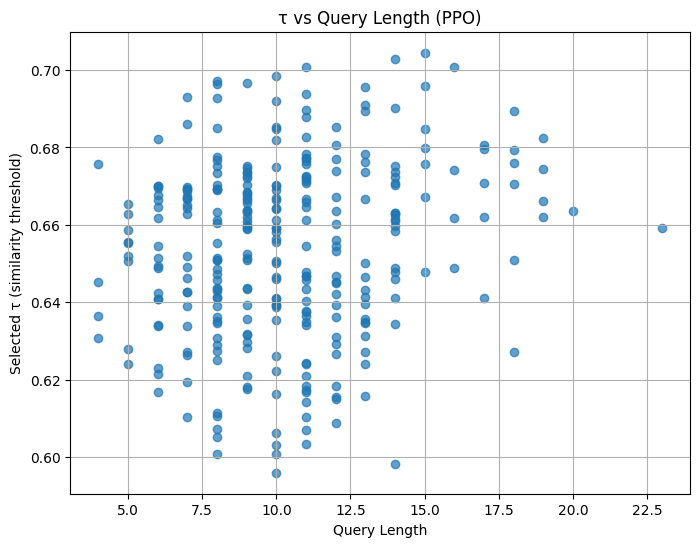

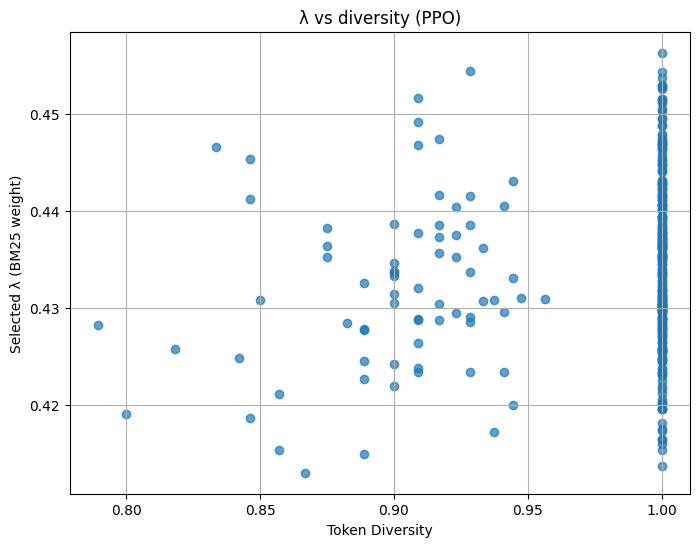

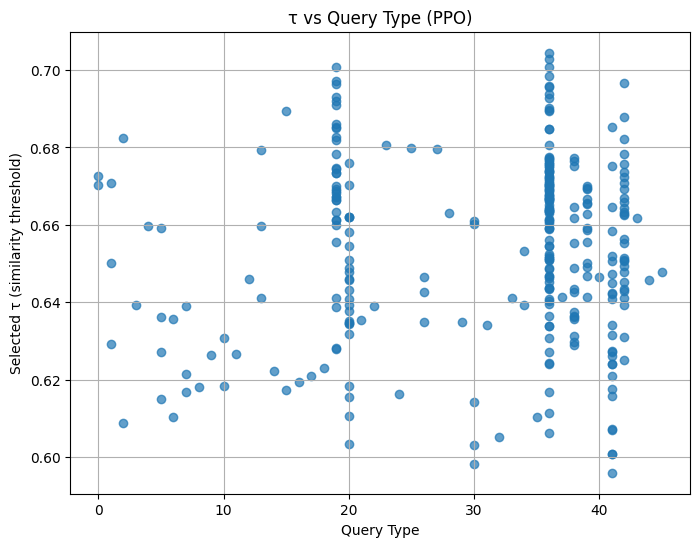

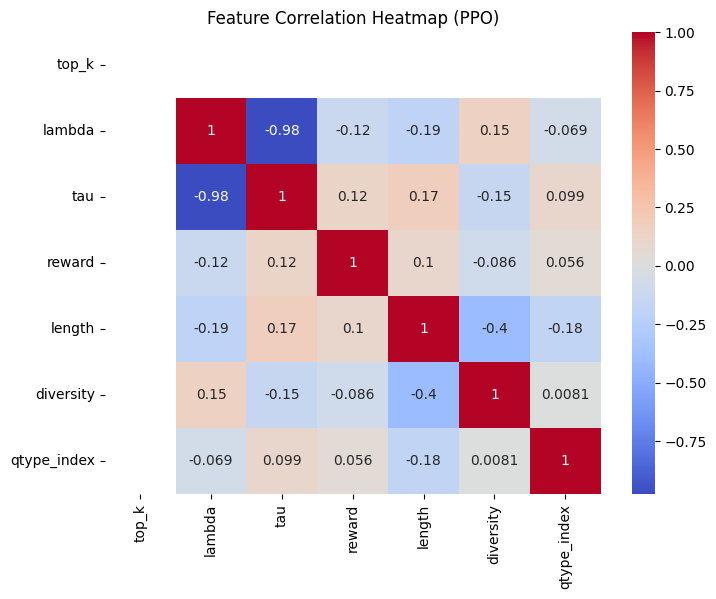

In [ ]:
import pandas as pd

ppo_df = pd.DataFrame(ppo_test_results)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(ppo_df["length"], ppo_df["top_k"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected top-k")
plt.title("top-k vs Query Length (PPO)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(ppo_df["length"], ppo_df["lambda"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected λ (BM25 weight)")
plt.title("λ vs Query Length (PPO)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(ppo_df["length"], ppo_df["tau"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Length (PPO)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(ppo_df["diversity"], ppo_df["lambda"], alpha=0.7)
plt.xlabel("Token Diversity")
plt.ylabel("Selected λ (BM25 weight)")
plt.title("λ vs diversity (PPO)")
plt.grid(True)
plt.show()


ppo_df["qtype_index"] = ppo_df["qtype"].astype("category").cat.codes
plt.figure(figsize=(8,6))
plt.scatter(ppo_df["qtype_index"], ppo_df["tau"], alpha=0.7)
plt.xlabel("Query Type")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Type (PPO)")
plt.grid(True)
plt.show()



import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(ppo_df[["top_k", "lambda", "tau", "reward", "length", "diversity", "qtype_index"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (PPO)")
plt.show()




In [ ]:
print(ppo_df[["top_k", "lambda", "tau", "reward", "length"]].corr())

        top_k    lambda       tau    reward    length
top_k     NaN       NaN       NaN       NaN       NaN
lambda    NaN  1.000000 -0.978156 -0.121172 -0.192755
tau       NaN -0.978156  1.000000  0.124325  0.174980
reward    NaN -0.121172  0.124325  1.000000  0.102056
length    NaN -0.192755  0.174980  0.102056  1.000000


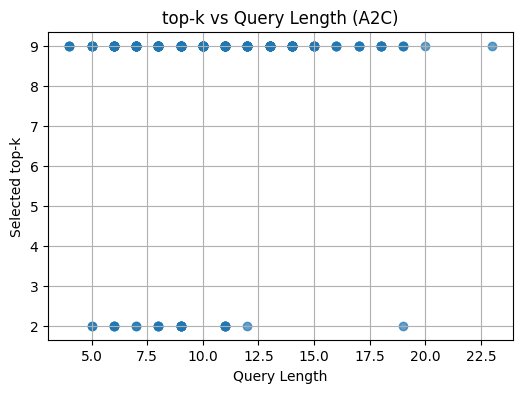

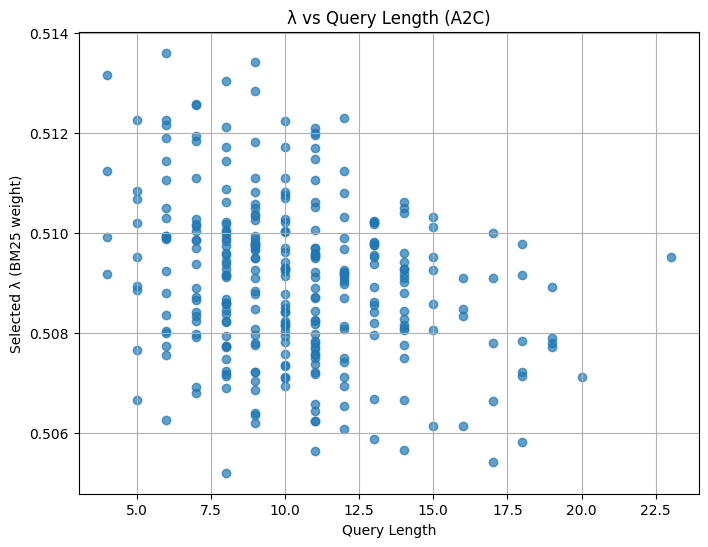

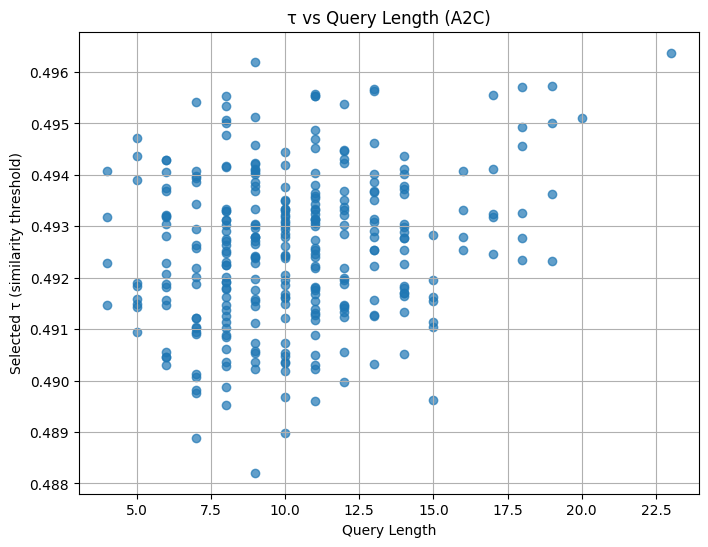

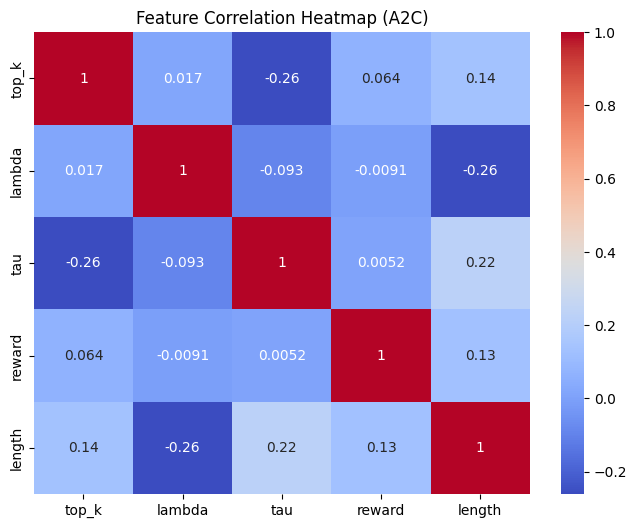

In [ ]:
import pandas as pd

a2c_df = pd.DataFrame(a2c_test_results)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(a2c_df["length"], a2c_df["top_k"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected top-k")
plt.title("top-k vs Query Length (A2C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(a2c_df["length"], a2c_df["lambda"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected λ (BM25 weight)")
plt.title("λ vs Query Length (A2C)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(a2c_df["length"], a2c_df["tau"], alpha=0.7)
plt.xlabel("Query Length")
plt.ylabel("Selected τ (similarity threshold)")
plt.title("τ vs Query Length (A2C)")
plt.grid(True)
plt.show()

import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(a2c_df[["top_k", "lambda", "tau", "reward", "length"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap (A2C)")
plt.show()




<ipython-input-76-05909f138914>:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_, labels=labels_, showmeans=True)  # show mean explicitly


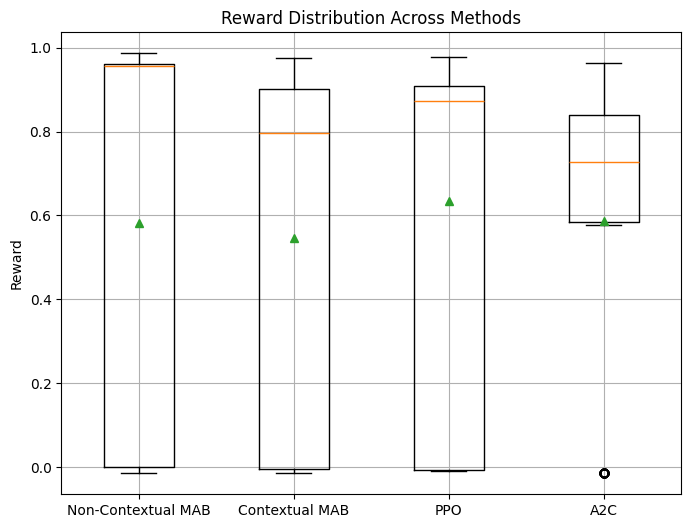

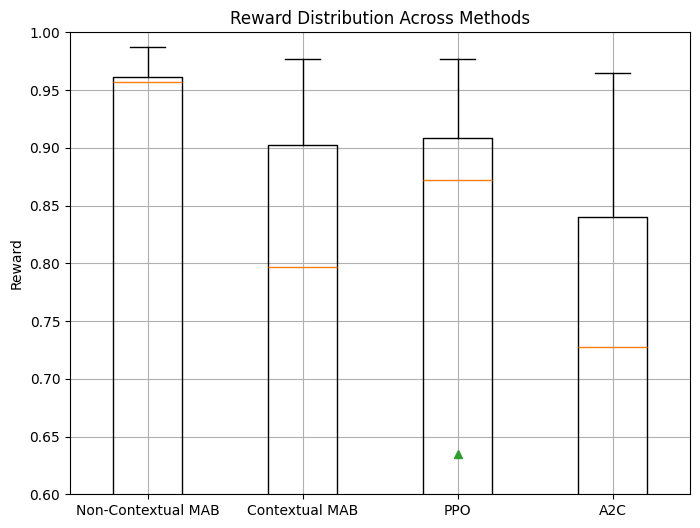

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Make sure each reward list is a 1D array
mab_rewards = np.array(mab_rewards).flatten()
cmab_rewards = np.array(cmab_rewards).flatten()
ppo_rewards = np.array(ppo_rewards).flatten()
a2c_rewards = np.array(a2c_rewards).flatten()


data_ = [mab_rewards, cmab_rewards, ppo_rewards, a2c_rewards]
labels_ = ['Non-Contextual MAB', 'Contextual MAB', 'PPO', 'A2C']

plt.figure(figsize=(8, 6))
plt.boxplot(data_, labels=labels_, showmeans=True)  # show mean explicitly
plt.title("Reward Distribution Across Methods")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

#plt.ylim(0, 1.0)
plt.show()

plt.figure(figsize=(8, 6))
plt.boxplot(data_, tick_labels=labels_, showmeans=True)  # <-- use tick_labels
plt.title("Reward Distribution Across Methods")
plt.ylabel("Reward")
plt.grid(True)

plt.ylim(0.6, 1.0)
plt.show()


In [ ]:
for name, rewards in zip(labels_, data_):
    print(f"{name}: Mean={np.mean(rewards):.4f}, Median={np.median(rewards):.4f}, Min={np.min(rewards):.4f}, Max={np.max(rewards):.4f}")


Non-Contextual MAB: Mean=0.5817, Median=0.9570, Min=-0.0150, Max=0.9870
Contextual MAB: Mean=0.5456, Median=0.7970, Min=-0.0150, Max=0.9765
PPO: Mean=0.6345, Median=0.8723, Min=-0.0095, Max=0.9770
A2C: Mean=0.5868, Median=0.7273, Min=-0.0138, Max=0.9647
